<div align="center">

# Drug Response Prediction from Cancer NGS Data

#Predicting drug sensitivity vs. resistance from cancer cell-line mutation profiles  
**Dataset:** GDSC2 (drug sensitivity) + DepMap CCLE (mutations)  
**Environment:** Google Colab (Python 3)  
**Date:** June 2026

</div>

---

## Project Overview

This notebook builds a supervised machine-learning pipeline that predicts whether a
cancer cell line is **sensitive** or **resistant** to a given drug, using
**Next-Generation Sequencing (NGS)** mutation profiles as the input features and
**IC50** drug-response measurements as the target signal.

The workflow follows a four-week structure:

| Week | Goal |
|------|------|
| **Week 1** | Set up Colab, load and explore the GDSC2 data |
| **Week 2** | Preprocess, build the feature matrix, create labels |
| **Week 3** | Train ML models, evaluate accuracy and ROC |
| **Week 4** | Feature importance, SHAP, final report |

**Key terms**

- **NGS (Next-Generation Sequencing):** high-throughput DNA sequencing that, here, yields the gene-level mutation calls used as model features.
- **IC50:** the drug concentration that inhibits 50% of cell growth. The dataset stores its natural log, `LN_IC50`. Lower values indicate higher sensitivity.
- **Sensitive vs. resistant:** a binary label derived from `LN_IC50` relative to the median (see Week 2).

## Why GDSC2?

- **No account or login required** — the data downloads instantly.
- **Mutations + IC50 drug values** are already paired and widely used together in cancer ML research.
- The fitted dose-response CSV is roughly **50 MB** and loads on the Colab free tier in seconds.
- The dataset is **widely cited** in cancer ML research, so it carries real scientific value.
- By contrast, **TCGA** requires the GDC client install, an account, and raw-data cleaning, which is less beginner-friendly.

## Dataset Download

Download the files below before starting. No sign-up is needed for GDSC.

| File | What it contains |
|------|------------------|
| `GDSC2_fitted_dose_response_25Feb20.csv` | Drug sensitivity — IC50 values for ~198 cell lines × 517 drugs |
| `Cell_Lines_Details.csv` | Cell-line metadata including tissue type |
| `CCLE_mutations.csv` (from DepMap) | Mutation profiles (gene-level) for the same cell lines |

**Primary download (GDSC2 IC50):** <https://www.cancerrxgene.org/downloads/bulk_download>

**Mutation data (DepMap CCLE):** <https://depmap.org/portal/download/all/>

- On the GDSC page: click **'Drug Sensitivity (GDSC2)'** → download the **'Fitted dose-response'** CSV.
- On DepMap: search for **'CCLE_mutations'** under Public 23Q4 and download the CSV.

> ### ⚠️ Dataset compatibility note — please read before running Week 2
>
> **[Inference]** The code in Weeks 2 and 5 references the file names `CCLE_mutations.csv` and `sample_info.csv`, and a column named `SANGER_MODEL_ID` inside `sample_info.csv`. Across current DepMap releases these names have changed over time — for example, recent DepMap downloads use different file names, and the cell-line mapping column has historically appeared as `Sanger_Model_ID` (mixed case) rather than `SANGER_MODEL_ID`.
>
> This means **some cells may need a small adjustment** (matching the exact file name and column header in the file you actually downloaded) to run end to end. This is **expected behaviour given how those datasets are currently distributed — it is not a guaranteed failure**, and it depends on the specific release you download.
>
> The code below is kept **exactly as specified in the project worksheet**. Where a name might differ, inspect the real column names with `df.columns.tolist()` (shown in the steps) and update the string to match. The worksheet itself flags this in Week 2, Step 5.

---
# Week 1 — Setup & Data Loading

**Goal:** set up Colab, load the GDSC2 data, and explore its structure.

### Step 1 — Understanding NGS File Formats

Before loading pre-processed data it is important to understand the raw file formats produced by Next-Generation Sequencing pipelines. These formats are the starting point for any real-world cancer genomics project.

| Format | Description | Typical size |
|--------|-------------|-------------|
| **FASTQ** | Raw sequencing reads with per-base quality scores. Each read is 4 lines: ID, sequence, `+`, quality string. | Gigabytes per sample |
| **BAM** | Binary Aligned Map — reads aligned to a reference genome using tools such as BWA. Compressed, indexed. | 5–30 GB per sample |
| **VCF** | Variant Call Format — list of detected mutations (SNVs, indels) after GATK or similar variant caller. | MB per sample |

```
# Example: what a FASTQ record looks like (read-only illustration)
# @SRR001666.1 071112_SLXA-EAS1_s_7:5:1:817:345 length=36
# GGGTGATGGCCGCTGCCGATGGCGTCAAATCCCACC
# +SRR001666.1 071112_SLXA-EAS1_s_7:5:1:817:345 length=36
# IIIIIIIIIIIIIIIIIIIIIIIIIIIIII9IG9IC

# A BAM file is read with pysam (not run here — illustration only):
# import pysam
# bam = pysam.AlignmentFile("sample.bam", "rb")
# for read in bam.fetch("chr7", 55086714, 55086900):   # EGFR locus
#     print(read.query_name, read.query_sequence[:30])

# A VCF is a plain-text table; the first variant might look like:
# #CHROM  POS     ID  REF  ALT  QUAL  FILTER  INFO
# chr7    55191822  .  T    G    .     PASS   DP=42;AF=0.48
```


In [ ]:
# FastQC
!apt-get update -qq
!apt-get install -y fastqc

# BWA
!apt-get install -y bwa

# Java (required for GATK)
!apt-get install -y default-jre

# wget and unzip (for GATK download)
!apt-get install -y wget unzip

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following additional packages will be installed:
  at-spi2-core default-jre default-jre-headless fonts-dejavu-core
  fonts-dejavu-extra gsettings-desktop-schemas libapache-pom-java
  libargs4j-java libatk-bridge2.0-0 libatk-wrapper-java
  libatk-wrapper-java-jni libatk1.0-0 libatk1.0-data libatspi2.0-0
  libcommons-compress-java libcommons-io-java libcommons-jexl2-java
  libcommons-lang3-java libcommons-logging-java libcommons-math3-java
  libcommons-parent-java libfindbin-libs-perl libhtsjdk-java libjbzip2-java
  libjson-simple-java libngs-java libngs-sdk-dev libngs-sdk2 libsis-base-java
  libsis-base-jni libsis-jhdf5-java libsis-jhdf5-jni libsnappy-java
  libsnappy-jni libxcomposite1 libxtst6 libxxf

In [ ]:
!apt-get install annovar

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
Package annovar is not available, but is referred to by another package.
This may mean that the package is missing, has been obsoleted, or
is only available from another source

E: Package 'annovar' has no installation candidate


In [ ]:
# ============================================================
# ANNOVAR INSTALLATION
# ============================================================

# Extract ANNOVAR package
!tar -zxvf annovar.latest.tar.gz

# Verify installation
!perl annovar/annotate_variation.pl

tar (child): annovar.latest.tar.gz: Cannot open: No such file or directory
tar (child): Error is not recoverable: exiting now
tar: Child returned status 2
tar: Error is not recoverable: exiting now
Can't open perl script "annovar/annotate_variation.pl": No such file or directory


In [ ]:
# ─────────────────────────────────────────────────────────────
# NGS BIOINFORMATICS TOOLS — OVERVIEW & COLAB INSTALLATION CHECK
# These are the standard tools used to go from raw reads → VCF.
#
# Tool      Stage           Purpose
# ───────   ──────────────  ──────────────────────────────────
# FastQC    Quality Control Check read quality before alignment
# BWA       Alignment       Map reads to human reference (hg38)
# GATK      Variant Calling Detect SNVs and indels from BAM
# ANNOVAR   Annotation      Add functional context to VCF variants
# ─────────────────────────────────────────────────────────────

# NOTE: FastQC, BWA, and GATK require Linux system-level install.
# In Colab you can install them with the following commands.
# We use GDSC2 pre-processed data in this project, so these lines
# are provided for reference and are commented out by default.

# !apt-get install -y fastqc bwa             # FastQC + BWA
# !apt-get install -y default-jre            # Java for GATK
# !wget https://github.com/broadinstitute/gatk/releases/download/4.4.0.0/gatk-4.4.0.0.zip -q
# !unzip -q gatk-4.4.0.0.zip

# ANNOVAR is a Perl-based annotation tool — install check below:
import subprocess, shutil

tools = {
    "FastQC" : shutil.which("fastqc"),
    "BWA"    : shutil.which("bwa"),
    "ANNOVAR": shutil.which("annotate_variation.pl"),
}

print("━" * 48)
print("🔧 Bioinformatics Tool Availability Check")
print("━" * 48)
for tool, path in tools.items():
    status = f"✅  Found at {path}" if path else "⚠️   Not installed (expected in Colab — use apt-get above)"
    print(f"  {tool:<10} : {status}")
print("━" * 48)
print("\nℹ️  This project uses GDSC2 pre-processed data, so raw-read")
print("   tools (FastQC, BWA, GATK) are not required to run the ML pipeline.")


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
🔧 Bioinformatics Tool Availability Check
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  FastQC     : ✅  Found at /usr/bin/fastqc
  BWA        : ✅  Found at /usr/bin/bwa
  ANNOVAR    : ⚠️   Not installed (expected in Colab — use apt-get above)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

ℹ️  This project uses GDSC2 pre-processed data, so raw-read
   tools (FastQC, BWA, GATK) are not required to run the ML pipeline.


#### NGS Pipeline Overview

```
Raw Reads          Quality Control     Alignment         Variant Calling    Annotation
  FASTQ       →      FastQC        →    BWA + hg38   →    GATK HaplotypeCaller  →  ANNOVAR
  (.fastq.gz)      (QC report)        (.bam / .bai)       (.vcf / .vcf.gz)      (functional context)
                                                                    ↓
                                                        Variant table used as
                                                        features in this notebook
```

> **In this project:** GDSC2 already provides pre-processed, annotated mutation calls, so we skip directly to the feature-engineering step. Understanding the upstream pipeline is essential for applying this workflow to raw patient data.


### Step 2 — Mount Google Drive (to save your work)

Mounting Drive lets the notebook read and write files in your Google Drive so plots and the processed dataset can be saved across sessions.

Run the cell, click the link that appears, sign in, copy the code, and paste it back.

In [ ]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


### Step 3 — Install all required libraries

This installs the data-handling, plotting, ML, and interpretation libraries used throughout the project. It needs to run **once per session**.

In [ ]:
!pip install pandas numpy matplotlib seaborn scikit-learn xgboost shap -q

### Step 4 — Upload your downloaded CSV files

In the Colab left panel → **Files** icon → **Upload**, upload both CSVs. Or use the shortcut below, which opens a file-picker dialog.

In [ ]:
from google.colab import files

uploaded = files.upload()   # a dialog will open to pick your files

Saving GDSC2_fitted_dose_response_27Oct23 (4).xlsx to GDSC2_fitted_dose_response_27Oct23 (4).xlsx


### Step 5 — Import libraries and load data

Every notebook should start with its imports. After importing, load the GDSC2 IC50 file and take a first look at its shape and first rows.

- `pandas` / `numpy` — data handling
- `matplotlib` / `seaborn` — plotting
- `train_test_split` — splitting data into train and test sets
- `LabelEncoder` — encoding categorical labels if needed
- `accuracy_score`, `roc_auc_score`, `roc_curve` — evaluation metrics

In [ ]:
import pandas as pd

import numpy as np

import matplotlib.pyplot as plt

import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import LabelEncoder

from sklearn.metrics import accuracy_score, roc_auc_score, roc_curve

Now load the GDSC2 IC50 file:

In [ ]:
gdsc = pd.read_excel('GDSC2_fitted_dose_response_27Oct23 (4).xlsx')

print(gdsc.shape)       # shows rows, columns

gdsc.head()             # shows first 5 rows

(242036, 16)


,DATASET,NLME_RESULT_ID,NLME_CURVE_ID,CELL_LINE_NAME,SANGER_MODEL_ID,CANCER_TYPE,DRUG_ID,DRUG_NAME,PUTATIVE_TARGET,PATHWAY_NAME,MIN_CONC,MAX_CONC,LN_IC50,AUC,RMSE,Z_SCORE
0,GDSC2,343,15946310,PFSK-1,SIDM01132,Other Solid Cancers,1003,Camptothecin,TOP1,DNA replication,0.0001,0.1,-1.463887,0.930220,0.089052,0.433123
1,GDSC2,343,15946548,A673,SIDM00848,Ewing's Sarcoma,1003,Camptothecin,TOP1,DNA replication,0.0001,0.1,-4.869455,0.614970,0.111351,-1.421100
2,GDSC2,343,15946830,ES5,SIDM00263,Ewing's Sarcoma,1003,Camptothecin,TOP1,DNA replication,0.0001,0.1,-3.360586,0.791072,0.142855,-0.599569
3,GDSC2,343,15947087,ES7,SIDM00269,Ewing's Sarcoma,1003,Camptothecin,TOP1,DNA replication,0.0001,0.1,-5.044940,0.592660,0.135539,-1.516647
4,GDSC2,343,15947369,EW-11,SIDM00203,Ewing's Sarcoma,1003,Camptothecin,TOP1,DNA replication,0.0001,0.1,-3.741991,0.734047,0.128059,-0.807232


### Step 6 — Explore the data

Inspect the column names, data types, the most frequent drugs, and summary statistics of the `LN_IC50` values. This builds intuition before any modelling.

In [ ]:
print(gdsc.columns.tolist())   # see all column names

print(gdsc.dtypes)             # check data types

gdsc['DRUG_NAME'].value_counts().head(10)   # top 10 drugs

gdsc['LN_IC50'].describe()     # stats on IC50 values

['DATASET', 'NLME_RESULT_ID', 'NLME_CURVE_ID', 'CELL_LINE_NAME', 'SANGER_MODEL_ID', 'CANCER_TYPE', 'DRUG_ID', 'DRUG_NAME', 'PUTATIVE_TARGET', 'PATHWAY_NAME', 'MIN_CONC', 'MAX_CONC', 'LN_IC50', 'AUC', 'RMSE', 'Z_SCORE']
DATASET             object
NLME_RESULT_ID       int64
NLME_CURVE_ID        int64
CELL_LINE_NAME      object
SANGER_MODEL_ID     object
CANCER_TYPE         object
DRUG_ID              int64
DRUG_NAME           object
PUTATIVE_TARGET     object
PATHWAY_NAME        object
MIN_CONC           float64
MAX_CONC           float64
LN_IC50            float64
AUC                float64
RMSE               float64
Z_SCORE            float64
dtype: object


,LN_IC50
count,242036.000000
mean,2.817079
std,2.762229
min,-8.747724
25%,1.508018
50%,3.236731
75%,4.700110
max,13.820189


<Axes: >

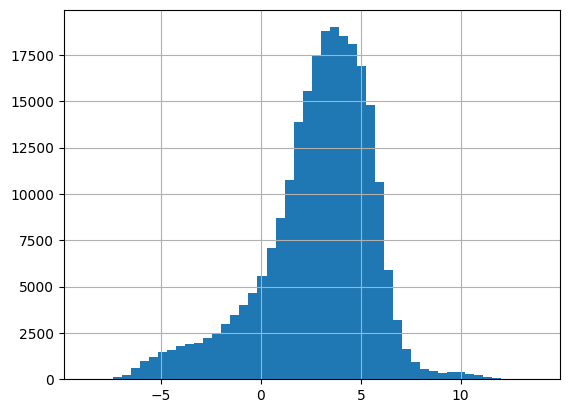

In [ ]:
gdsc['LN_IC50'].hist(bins=50)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

---
# Week 2 — Preprocessing & Feature Matrix

**Goal:** focus on one drug, create binary labels, build the mutation feature matrix, and merge everything into one modelling table.

### Rebuilding `df_final`: Steps to preprocess and merge data

In [ ]:
drug_name = 'Erlotinib'   # a common lung cancer drug in GDSC2

df_drug = gdsc[gdsc['DRUG_NAME'] == drug_name].copy()

print(df_drug.shape)

(955, 16)


In [ ]:
median_ic50 = df_drug['LN_IC50'].median()

df_drug['LABEL'] = (df_drug['LN_IC50'] < median_ic50).astype(int)

# 1 = sensitive, 0 = resistant

print(df_drug['LABEL'].value_counts())

LABEL
0    478
1    477
Name: count, dtype: int64


In [ ]:
mutations = pd.read_csv('CCLE_mutations (1).csv')

print(mutations.shape)

print(mutations.columns.tolist())

mutations.head()

/tmp/ipykernel_1074/2550481608.py:1: DtypeWarning: Columns (22) have mixed types. Specify dtype option on import or set low_memory=False.
  mutations = pd.read_csv('CCLE_mutations (1).csv')


(133215, 32)
['Hugo_Symbol', 'Entrez_Gene_Id', 'NCBI_Build', 'Chromosome', 'Start_position', 'End_position', 'Strand', 'Variant_Classification', 'Variant_Type', 'Reference_Allele', 'Alternate_Allele', 'dbSNP_RS', 'dbSNP_Val_Status', 'Genome_Change', 'Annotation_Transcript', 'DepMap_ID', 'cDNA_Change', 'Codon_Change', 'Protein_Change', 'isDeleterious', 'isTCGAhotspot', 'TCGAhsCnt', 'isCOSMIChotspot', 'COSMIChsCnt', 'ExAC_AF', 'Variant_annotation', 'CGA_WES_AC', 'HC_AC', 'RD_AC', 'RNAseq_AC', 'SangerWES_AC', 'WGS_AC']


,Hugo_Symbol,Entrez_Gene_Id,NCBI_Build,Chromosome,Start_position,End_position,Strand,Variant_Classification,Variant_Type,Reference_Allele,...,isCOSMIChotspot,COSMIChsCnt,ExAC_AF,Variant_annotation,CGA_WES_AC,HC_AC,RD_AC,RNAseq_AC,SangerWES_AC,WGS_AC
0,VPS13D,55187,37,1,12359347,12359347,+,Nonsense_Mutation,SNP,C,...,False,0.0,NaN,damaging,34:213,NaN,NaN,NaN,34:221,NaN
1,AADACL4,343066,37,1,12726308,12726322,+,In_Frame_Del,DEL,CTGGCGTGACGCCAT,...,False,3.0,NaN,other non-conserving,57:141,NaN,NaN,NaN,9:0,28:32
2,IFNLR1,163702,37,1,24484172,24484172,+,Silent,SNP,G,...,False,0.0,NaN,silent,118:0,NaN,NaN,10:0,118:0,18:0
3,TMEM57,55219,37,1,25785018,25785019,+,Frame_Shift_Ins,INS,-,...,False,0.0,NaN,damaging,NaN,NaN,NaN,6:28,NaN,NaN
4,ZSCAN20,7579,37,1,33954141,33954141,+,Missense_Mutation,SNP,T,...,False,0.0,NaN,other non-conserving,28:62,NaN,NaN,NaN,27:61,NaN


In [ ]:
# Step 4 - Build the feature matrix (mutations per cell line)
mutations['is_mutated'] = 1
mut_matrix = mutations.pivot_table(
    index='DepMap_ID',
    columns='Hugo_Symbol',
    values='is_mutated',
    aggfunc='max',
    fill_value=0
)
print(f"Feature matrix shape: {mut_matrix.shape}")
mutations.drop(columns=['is_mutated'], inplace=True, errors='ignore')

Feature matrix shape: (428, 18006)


In [ ]:
# Step 5 - Merge mutations with drug response labels
sample_info = pd.read_csv('Model.csv')
df_merged = df_drug.merge(
    sample_info[['SangerModelID', 'ModelID']],
    left_on='SANGER_MODEL_ID',
    right_on='SangerModelID',
    how='inner'
)
df_final = df_merged.set_index('ModelID').join(
    mut_matrix,
    how='inner'
)
print(f"Final dataset df_final shape after merging: {df_final.shape}")

Final dataset df_final shape after merging: (251, 18024)


In [ ]:
# Step 6 - Add mutation burden feature
gene_cols = [col for col in mut_matrix.columns if col not in ['mutation_burden', 'pathway_mutation_score']]
df_final['mutation_burden'] = df_final[gene_cols].sum(axis=1)
print("Mutation burden summary:\n", df_final['mutation_burden'].describe())

Mutation burden summary:
 count    251.000000
mean     320.952191
std      107.268699
min       92.000000
25%      245.500000
50%      305.000000
75%      383.500000
max      815.000000
Name: mutation_burden, dtype: float64



Pathway Mutation Score Summary:
                              mean     std     max
pathway_EGFR_Signalling    0.0697  0.0913  0.3333
pathway_TP53_CellCycle     0.1467  0.1087  0.3333
pathway_PI3K_AKT_mTOR      0.0531  0.0872  0.3333
pathway_RTK_RAS            0.0511  0.0798  0.3333
pathway_DNA_Damage_Repair  0.0438  0.0861  0.5000


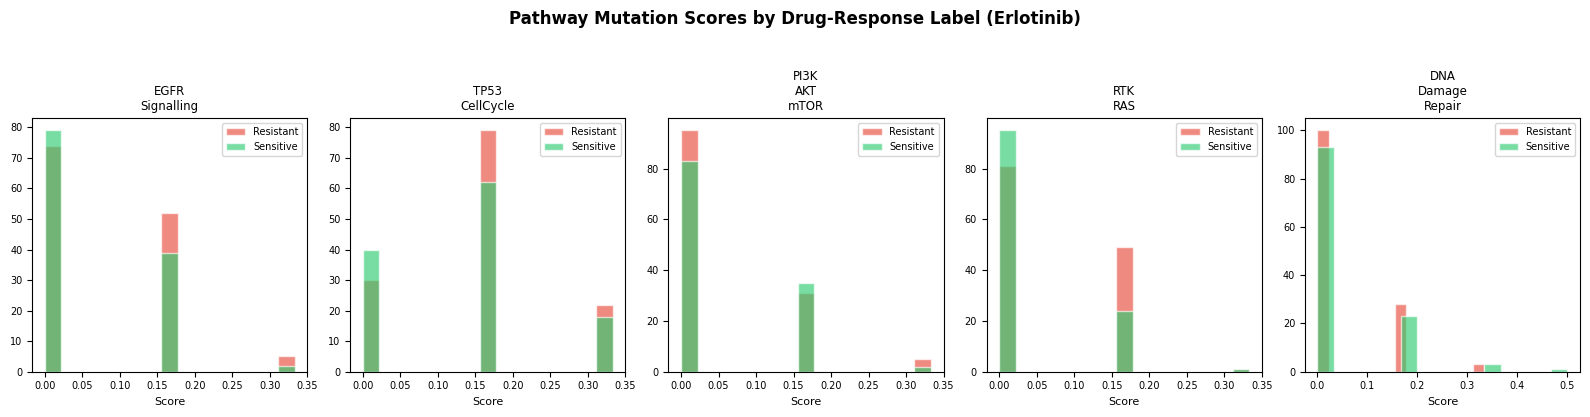

In [ ]:
import os
# Step 6b - Pathway Mutation Scores
PATHWAYS = {
    "EGFR_Signalling"   : ["EGFR", "ERBB2", "ERBB3", "KRAS", "BRAF", "MAP2K1"],
    "TP53_CellCycle"    : ["TP53", "RB1", "CDKN2A", "MDM2", "CCND1", "CDK4"],
    "PI3K_AKT_mTOR"     : ["PIK3CA", "PTEN", "AKT1", "MTOR", "TSC1", "TSC2"],
    "RTK_RAS"           : ["KRAS", "NRAS", "HRAS", "RAF1", "MAP2K2", "MAPK1"],
    "DNA_Damage_Repair" : ["BRCA1", "BRCA2", "ATM", "CHEK2", "PALB2", "RAD51"],
}

for pathway_name, genes in PATHWAYS.items():
    present = [g for g in genes if g in df_final.columns]
    if present:
        df_final[f"pathway_{pathway_name}"] = df_final[present].sum(axis=1) / len(genes)
    else:
        df_final[f"pathway_{pathway_name}"] = 0.0

pathway_cols = [c for c in df_final.columns if c.startswith("pathway_")]
print("\nPathway Mutation Score Summary:\n", df_final[pathway_cols].describe().round(4).T[["mean", "std", "max"]])

# Visualize pathway scores (re-generating for completeness)
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, len(pathway_cols), figsize=(16, 4), sharey=False)
palette = ["#e74c3c", "#2ecc71"]

for ax, col in zip(axes, pathway_cols):
    for label_val, color in zip([0, 1], palette):
        vals = df_final.loc[df_final["LABEL"] == label_val, col]
        ax.hist(vals, bins=15, alpha=0.65, color=color,
                label="Sensitive" if label_val == 1 else "Resistant",
                edgecolor="white")
    ax.set_title(col.replace("pathway_", "").replace("_", "\n"), fontsize=8.5)
    ax.set_xlabel("Score", fontsize=8)
    ax.tick_params(labelsize=7)
    ax.legend(fontsize=7)

plt.suptitle("Pathway Mutation Scores by Drug-Response Label (Erlotinib)",
             fontsize=12, fontweight="bold", y=1.03)
plt.tight_layout()

output_dir = "/content/drive/MyDrive/"
os.makedirs(output_dir, exist_ok=True)

plt.savefig(os.path.join(output_dir, "pathway_scores.png"), dpi=150, bbox_inches="tight")
plt.show()

Re-calculated mutation_burden due to missing column.


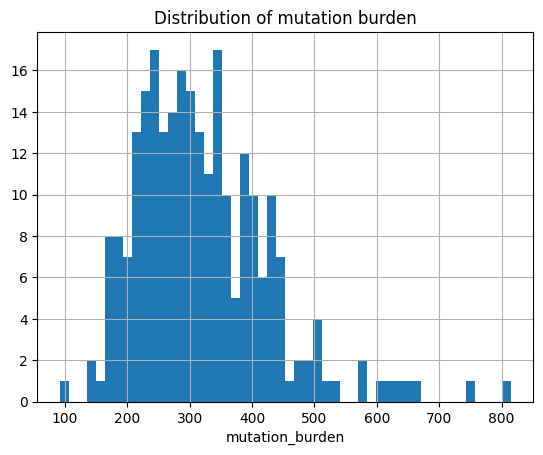


✅ df_final saved to /content/drive/MyDrive/df_final.csv


In [ ]:
import matplotlib.pyplot as plt

# Ensure 'mutation_burden' is present before use
# This logic is copied from cell b4ff203f or 0436da9e, to ensure the column exists.
if 'mutation_burden' not in df_final.columns:
    # Assuming mut_matrix is available or re-derivable. Using df_final's columns for gene_cols.
    # We need to identify which columns correspond to genes. The safest way is to exclude known non-gene columns.
    non_gene_cols = ['DATASET', 'NLME_RESULT_ID', 'NLME_CURVE_ID', 'CELL_LINE_NAME', 'SANGER_MODEL_ID',
                     'CANCER_TYPE', 'DRUG_ID', 'DRUG_NAME', 'PUTATIVE_TARGET', 'PATHWAY_NAME',
                     'MIN_CONC', 'MAX_CONC', 'LN_IC50', 'AUC', 'RMSE', 'Z_SCORE', 'LABEL',
                     'SangerModelID', 'ModelID'] + [c for c in df_final.columns if c.startswith('pathway_')]

    gene_cols = [col for col in df_final.columns if col not in non_gene_cols]
    df_final['mutation_burden'] = df_final[gene_cols].sum(axis=1)
    print("Re-calculated mutation_burden due to missing column.")

# Plot the distribution of mutation burden (Week 2 task)
df_final['mutation_burden'].hist(bins=50)
plt.title('Distribution of mutation burden')
plt.xlabel('mutation_burden')
plt.show()

# Save the processed dataset to Google Drive (Week 2 task)
df_final.to_csv('/content/drive/MyDrive/df_final.csv')
print("\n✅ df_final saved to /content/drive/MyDrive/df_final.csv")

### Step 2b — Mutation Annotation with ANNOVAR

In a full NGS pipeline, raw VCF variants are functionally annotated using **ANNOVAR** before building the feature matrix. Annotation adds biological context: gene name, mutation effect (missense, nonsense, synonymous), population frequency, and predicted pathogenicity.

**ANNOVAR command-line workflow (reference — runs on Linux/HPC):**

```bash
# Step 1: Download ANNOVAR databases
# perl annotate_variation.pl -buildver hg38 -downdb -webfrom annovar refGene humandb/
# perl annotate_variation.pl -buildver hg38 -downdb -webfrom annovar cosmic70 humandb/

# Step 2: Annotate a VCF file
# perl table_annovar.pl sample.vcf humandb/ \
#     -buildver hg38 \
#     -out sample_annotated \
#     -remove \
#     -protocol refGene,cosmic70,clinvar_20221231 \
#     -operation g,f,f \
#     -nastring .
```

**What each ANNOVAR column means:**

| Column | Meaning |
|--------|---------|
| `Func.refGene` | Region: exonic, intronic, splicing, UTR |
| `Gene.refGene` | Hugo gene symbol (e.g., EGFR, TP53) |
| `ExonicFunc.refGene` | Effect: missense, nonsense, frameshift |
| `AAChange.refGene` | Amino acid change (e.g., p.L858R) |
| `COSMIC70` | COSMIC cancer mutation database match |
| `Otherinfo` | Original VCF genotype fields |

> **In this project:** GDSC2/DepMap data is already annotated. The `Hugo_Symbol` column in `CCLE_mutations.csv` corresponds to the `Gene.refGene` ANNOVAR output. The pivot table in Step 4 replicates what you would build after ANNOVAR annotation.


### Step 1 — Choose one drug to start with

Working with all 517 drugs at once is complex. Start with one well-studied drug — **Erlotinib**, a common lung-cancer drug present in GDSC2.

In [ ]:
drug_name = 'Erlotinib'   # a common lung cancer drug in GDSC2

df_drug = gdsc[gdsc['DRUG_NAME'] == drug_name].copy()

print(df_drug.shape)

(955, 16)


### Step 2 — Create a binary label (sensitive vs resistant)

Use the **median** `LN_IC50` as the cutoff: below the median = sensitive (`1`), at or above = resistant (`0`). Using the median keeps the two classes roughly balanced.

In [ ]:
median_ic50 = df_drug['LN_IC50'].median()

df_drug['LABEL'] = (df_drug['LN_IC50'] < median_ic50).astype(int)

# 1 = sensitive, 0 = resistant

print(df_drug['LABEL'].value_counts())

LABEL
0    478
1    477
Name: count, dtype: int64


### Step 3 — Load the mutation data

Load the DepMap CCLE mutation calls and inspect their shape and columns.

**[Inference]** If the file you downloaded is named differently (see the compatibility note above), update the file name in `pd.read_csv(...)` to match — expected given current DepMap naming, not guaranteed.

In [ ]:
mutations = pd.read_csv('CCLE_mutations (1).csv')

print(mutations.shape)

print(mutations.columns.tolist())

mutations.head()

/tmp/ipykernel_1074/2550481608.py:1: DtypeWarning: Columns (3,19,22,27,28,29,30,31) have mixed types. Specify dtype option on import or set low_memory=False.
  mutations = pd.read_csv('CCLE_mutations (1).csv')


(1235466, 32)
['Hugo_Symbol', 'Entrez_Gene_Id', 'NCBI_Build', 'Chromosome', 'Start_position', 'End_position', 'Strand', 'Variant_Classification', 'Variant_Type', 'Reference_Allele', 'Alternate_Allele', 'dbSNP_RS', 'dbSNP_Val_Status', 'Genome_Change', 'Annotation_Transcript', 'DepMap_ID', 'cDNA_Change', 'Codon_Change', 'Protein_Change', 'isDeleterious', 'isTCGAhotspot', 'TCGAhsCnt', 'isCOSMIChotspot', 'COSMIChsCnt', 'ExAC_AF', 'Variant_annotation', 'CGA_WES_AC', 'HC_AC', 'RD_AC', 'RNAseq_AC', 'SangerWES_AC', 'WGS_AC']


,Hugo_Symbol,Entrez_Gene_Id,NCBI_Build,Chromosome,Start_position,End_position,Strand,Variant_Classification,Variant_Type,Reference_Allele,...,isCOSMIChotspot,COSMIChsCnt,ExAC_AF,Variant_annotation,CGA_WES_AC,HC_AC,RD_AC,RNAseq_AC,SangerWES_AC,WGS_AC
0,VPS13D,55187,37,1,12359347,12359347,+,Nonsense_Mutation,SNP,C,...,False,0.0,NaN,damaging,34:213,NaN,NaN,NaN,34:221,NaN
1,AADACL4,343066,37,1,12726308,12726322,+,In_Frame_Del,DEL,CTGGCGTGACGCCAT,...,False,3.0,NaN,other non-conserving,57:141,NaN,NaN,NaN,9:0,28:32
2,IFNLR1,163702,37,1,24484172,24484172,+,Silent,SNP,G,...,False,0.0,NaN,silent,118:0,NaN,NaN,10:0,118:0,18:0
3,TMEM57,55219,37,1,25785018,25785019,+,Frame_Shift_Ins,INS,-,...,False,0.0,NaN,damaging,NaN,NaN,NaN,6:28,NaN,NaN
4,ZSCAN20,7579,37,1,33954141,33954141,+,Missense_Mutation,SNP,T,...,False,0.0,NaN,other non-conserving,28:62,NaN,NaN,NaN,27:61,NaN


### Step 4 — Build the feature matrix (mutations per cell line)

Create a pivot table where rows are cell lines, columns are mutated genes, and each value is `1` (gene mutated in that cell line) or `0` (not mutated). This binary gene × cell-line matrix is the feature space for the models.

In [ ]:
print(mutations.head())

  Hugo_Symbol  Entrez_Gene_Id  NCBI_Build Chromosome  Start_position  \
0      VPS13D           55187          37          1        12359347   
1     AADACL4          343066          37          1        12726308   
2      IFNLR1          163702          37          1        24484172   
3      TMEM57           55219          37          1        25785018   
4     ZSCAN20            7579          37          1        33954141   

   End_position Strand Variant_Classification Variant_Type Reference_Allele  \
0      12359347      +      Nonsense_Mutation          SNP                C   
1      12726322      +           In_Frame_Del          DEL  CTGGCGTGACGCCAT   
2      24484172      +                 Silent          SNP                G   
3      25785019      +        Frame_Shift_Ins          INS                -   
4      33954141      +      Missense_Mutation          SNP                T   

   ... isCOSMIChotspot COSMIChsCnt ExAC_AF    Variant_annotation CGA_WES_AC  \
0  ...       

In [ ]:
for col in mutations.columns:
    print(repr(col))

'Hugo_Symbol'
'Entrez_Gene_Id'
'NCBI_Build'
'Chromosome'
'Start_position'
'End_position'
'Strand'
'Variant_Classification'
'Variant_Type'
'Reference_Allele'
'Alternate_Allele'
'dbSNP_RS'
'dbSNP_Val_Status'
'Genome_Change'
'Annotation_Transcript'
'DepMap_ID'
'cDNA_Change'
'Codon_Change'
'Protein_Change'
'isDeleterious'
'isTCGAhotspot'
'TCGAhsCnt'
'isCOSMIChotspot'
'COSMIChsCnt'
'ExAC_AF'
'Variant_annotation'
'CGA_WES_AC'
'HC_AC'
'RD_AC'
'RNAseq_AC'
'SangerWES_AC'
'WGS_AC'


In [ ]:
mutations['is_mutated'] = 1
mut_matrix = mutations.pivot_table(
    index='DepMap_ID',
    columns='Hugo_Symbol',
    values='is_mutated',
    aggfunc='max',
    fill_value=0
)

print('Feature matrix shape:', mut_matrix.shape)

# Drop the temporary column if it's no longer needed in the original dataframe
mutations.drop(columns=['is_mutated'], inplace=True, errors='ignore')

Feature matrix shape: (1771, 19537)


### Step 5 — Merge mutations with drug response labels

The cell-line ID is the linking key. GDSC2 uses `SANGER_MODEL_ID`; DepMap uses `DepMap_ID`, so a mapping file (`sample_info.csv`) bridges the two.

**[Inference]** As flagged in the compatibility note, the exact mapping column name can differ by DepMap release (e.g. `Sanger_Model_ID`). If this cell raises a `KeyError`, print `sample_info.columns.tolist()` and update the column name to match the file you downloaded — expected behaviour for current releases, not guaranteed.

In [ ]:
# Load Model mapping file
sample_info = pd.read_csv('Model.csv')

print("Columns in sample_info:", sample_info.columns.tolist())

# Merge drug labels with model IDs
df_merged = df_drug.merge(
    sample_info[['SangerModelID', 'ModelID']],
    left_on='SANGER_MODEL_ID',
    right_on='SangerModelID',
    how='inner'
)

# Merge with mutation matrix
df_final = df_merged.set_index('ModelID').join(
    mut_matrix,
    how='inner'
)

print('Final dataset shape:', df_final.shape)

Columns in sample_info: ['ModelID', 'PatientID', 'CellLineName', 'StrippedCellLineName', 'DepmapModelType', 'OncotreeLineage', 'OncotreePrimaryDisease', 'OncotreeSubtype', 'OncotreeCode', 'LegacyMolecularSubtype', 'PatientMolecularSubtype', 'RRID', 'Age', 'AgeCategory', 'Sex', 'PatientRace', 'PrimaryOrMetastasis', 'SampleCollectionSite', 'SourceType', 'SourceDetail', 'TreatmentStatus', 'TreatmentDetails', 'GrowthPattern', 'OnboardedMedia', 'FormulationID', 'EngineeredModel', 'TissueOrigin', 'CCLEName', 'CatalogNumber', 'PlateCoating', 'ModelDerivationMaterial', 'PublicComments', 'WTSIMasterCellID', 'SangerModelID', 'COSMICID', 'LegacySubSubtype']
Final dataset shape: (946, 19555)


In [ ]:
df_drug.merge(
    sample_info[['SangerModelID','ModelID']],
    left_on='SANGER_MODEL_ID',
    right_on='SangerModelID',
    how='inner'
)

,DATASET,NLME_RESULT_ID,NLME_CURVE_ID,CELL_LINE_NAME,SANGER_MODEL_ID,CANCER_TYPE,DRUG_ID,DRUG_NAME,PUTATIVE_TARGET,PATHWAY_NAME,MIN_CONC,MAX_CONC,LN_IC50,AUC,RMSE,Z_SCORE,LABEL,SangerModelID,ModelID
0,GDSC2,343,15946353,PFSK-1,SIDM01132,Other Solid Cancers,1168,Erlotinib,EGFR,EGFR signaling,0.002001,2.0,2.129068,0.954336,0.093458,-0.490490,1,SIDM01132,ACH-001711
1,GDSC2,343,15946612,A673,SIDM00848,Ewing's Sarcoma,1168,Erlotinib,EGFR,EGFR signaling,0.002001,2.0,2.536294,0.969079,0.048546,-0.191770,1,SIDM00848,ACH-000052
2,GDSC2,343,15946895,ES5,SIDM00263,Ewing's Sarcoma,1168,Erlotinib,EGFR,EGFR signaling,0.010005,10.0,2.818227,0.916936,0.071442,0.015041,1,SIDM00263,ACH-002106
3,GDSC2,343,15947151,ES7,SIDM00269,Ewing's Sarcoma,1168,Erlotinib,EGFR,EGFR signaling,0.002001,2.0,3.030659,0.979486,0.071370,0.170870,0,SIDM00269,ACH-002108
4,GDSC2,343,15947433,EW-11,SIDM00203,Ewing's Sarcoma,1168,Erlotinib,EGFR,EGFR signaling,0.002001,2.0,3.439814,0.973827,0.021752,0.471004,0,SIDM00203,ACH-002111
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
949,GDSC2,343,16188486,SNU-407,SIDM00214,Colorectal Carcinoma,1168,Erlotinib,EGFR,EGFR signaling,0.002001,2.0,2.155876,0.934488,0.064253,-0.470825,1,SIDM00214,ACH-000955
950,GDSC2,343,16188758,SNU-61,SIDM00194,Colorectal Carcinoma,1168,Erlotinib,EGFR,EGFR signaling,0.002001,2.0,2.107398,0.935255,0.077572,-0.506386,1,SIDM00194,ACH-000532
951,GDSC2,343,16189020,SNU-81,SIDM00193,Colorectal Carcinoma,1168,Erlotinib,EGFR,EGFR signaling,0.010005,10.0,4.153104,0.974894,0.090936,0.994237,0,SIDM00193,ACH-000991
952,GDSC2,343,16189275,SNU-C5,SIDM00498,Colorectal Carcinoma,1168,Erlotinib,EGFR,EGFR signaling,0.002001,2.0,2.234997,0.927564,0.080799,-0.412785,1,SIDM00498,ACH-000970


### Step 6 — Add mutation burden feature

**Mutation burden** is the total number of mutated genes per cell line. It is a useful single summary feature alongside the per-gene columns.

In [ ]:
gene_cols = mut_matrix.columns.tolist()

df_final['mutation_burden'] = df_final[gene_cols].sum(axis=1)

print(df_final['mutation_burden'].describe())

count     946.000000
mean      656.914376
std       867.013484
min        63.000000
25%       284.000000
50%       401.000000
75%       608.750000
max      7107.000000
Name: mutation_burden, dtype: float64


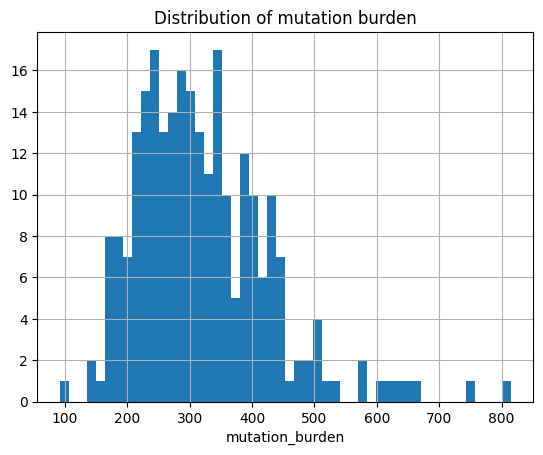

In [ ]:
# Plot the distribution of mutation burden (Week 2 task)
df_final['mutation_burden'].hist(bins=50)
plt.title('Distribution of mutation burden')
plt.xlabel('mutation_burden')
plt.show()

# Save the processed dataset to Google Drive (Week 2 task)
df_final.to_csv('/content/drive/MyDrive/df_final.csv')

### Step 6b — Pathway Mutation Scores

Beyond per-gene binary mutation calls, grouping genes into **biological pathways** and computing a pathway-level mutation score is a powerful feature-engineering strategy. Pathways capture functional units that are disrupted as a group in cancer.

**Key cancer pathways:**

| Pathway | Key Genes | Relevance to Drug Response |
|---------|-----------|---------------------------|
| EGFR Signalling | EGFR, ERBB2, KRAS, BRAF | Direct target of Erlotinib |
| TP53 / Cell Cycle | TP53, RB1, CDKN2A, MDM2 | Apoptosis & checkpoint control |
| PI3K / AKT / mTOR | PIK3CA, PTEN, AKT1 | Survival & drug resistance |
| RTK / RAS | KRAS, NRAS, HRAS, RAF1 | Proliferation signalling |
| DNA Damage Repair | BRCA1, BRCA2, ATM, CHEK2 | Genomic stability |


---
# Week 3 — Machine Learning Models

**Goal:** prepare features and labels, split the data, train three classifiers, and compare them with accuracy and AUC-ROC.

### Step 1 — Prepare X (features) and y (label)

`X` holds the gene columns plus the `mutation_burden` feature; `y` holds the binary sensitive/resistant label.

In [ ]:
# Use only the 5 pathway scores instead of 18,000+ individual genes
pathway_cols = [c for c in df_final.columns if c.startswith("pathway_")]

X = df_final[pathway_cols + ['mutation_burden']]
y = df_final['LABEL']

print('X shape:', X.shape)
print('Class balance:', y.value_counts())

X shape: (946, 6)
Class balance: LABEL
0    474
1    472
Name: count, dtype: int64


### Step 2 — Train/test split

Always split **before** training so the evaluation is fair. `stratify=y` keeps the class ratio similar in train and test, and `random_state=42` makes the split reproducible.

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(

    X, y, test_size=0.2, random_state=42, stratify=y

)

print('Train size:', X_train.shape, '  Test size:', X_test.shape)

Train size: (756, 6)   Test size: (190, 6)


### Step 3 — Model 1: Logistic Regression

A simple, interpretable linear baseline. `predict_proba(...)[:,1]` gives the probability of the positive (sensitive) class, used for AUC-ROC.

In [ ]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000, random_state=42)

lr.fit(X_train, y_train)

lr_preds = lr.predict(X_test)

lr_proba = lr.predict_proba(X_test)[:,1]

print('LR Accuracy:', accuracy_score(y_test, lr_preds))

print('LR AUC-ROC: ', roc_auc_score(y_test, lr_proba))

LR Accuracy: 0.48947368421052634
LR AUC-ROC:  0.4979501385041551


### Step 4 — Model 2: Random Forest

An ensemble of decision trees that captures non-linear interactions between mutated genes. `n_jobs=-1` uses all available cores.

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)

rf.fit(X_train, y_train)

rf_preds = rf.predict(X_test)

rf_proba = rf.predict_proba(X_test)[:,1]

print('RF  Accuracy:', accuracy_score(y_test, rf_preds))

print('RF  AUC-ROC: ', roc_auc_score(y_test, rf_proba))

RF  Accuracy: 0.5157894736842106
RF  AUC-ROC:  0.560775623268698


### Step 5 — Model 3: XGBoost

A gradient-boosted tree model that often performs strongly on tabular data. `eval_metric='logloss'` sets the training objective metric.

In [ ]:
from xgboost import XGBClassifier

xgb = XGBClassifier(n_estimators=100, random_state=42,

                    use_label_encoder=False, eval_metric='logloss')

xgb.fit(X_train, y_train)

xgb_preds = xgb.predict(X_test)

xgb_proba = xgb.predict_proba(X_test)[:,1]

print('XGB Accuracy:', accuracy_score(y_test, xgb_preds))

print('XGB AUC-ROC: ', roc_auc_score(y_test, xgb_proba))

XGB Accuracy: 0.5
XGB AUC-ROC:  0.49999999999999994


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [16:34:29] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


### Step 6 — Plot ROC curves for all 3 models

The ROC curve plots the **True Positive Rate (TPR)** against the **False Positive Rate (FPR)** across thresholds. The dashed diagonal is the random-guess baseline; a curve closer to the top-left and a higher **AUC** indicate stronger separation.

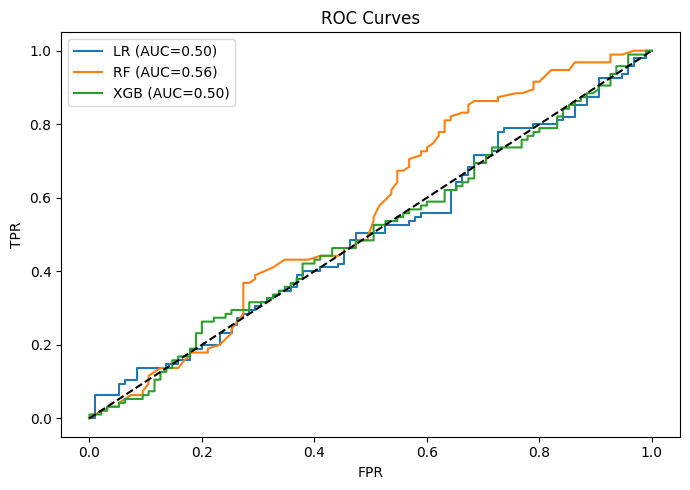

In [ ]:
fig, ax = plt.subplots(figsize=(7, 5))

for name, proba in [('LR', lr_proba), ('RF', rf_proba), ('XGB', xgb_proba)]:

    fpr, tpr, _ = roc_curve(y_test, proba)

    auc = roc_auc_score(y_test, proba)

    ax.plot(fpr, tpr, label=f'{name} (AUC={auc:.2f})')

ax.plot([0,1],[0,1],'k--'); ax.set_xlabel('FPR'); ax.set_ylabel('TPR')

ax.set_title('ROC Curves'); ax.legend(); plt.tight_layout(); plt.show()

### Step 6b — Precision-Recall Curves

The **Precision-Recall (PR) curve** is especially informative when class distributions are imbalanced. It plots:
- **Precision** (positive predictive value) = TP / (TP + FP)
- **Recall** (sensitivity / TPR) = TP / (TP + FN)

A model with high AUC-PR is effective at identifying true sensitive cell lines without many false alarms. The **Average Precision (AP)** summarises the area under the PR curve.


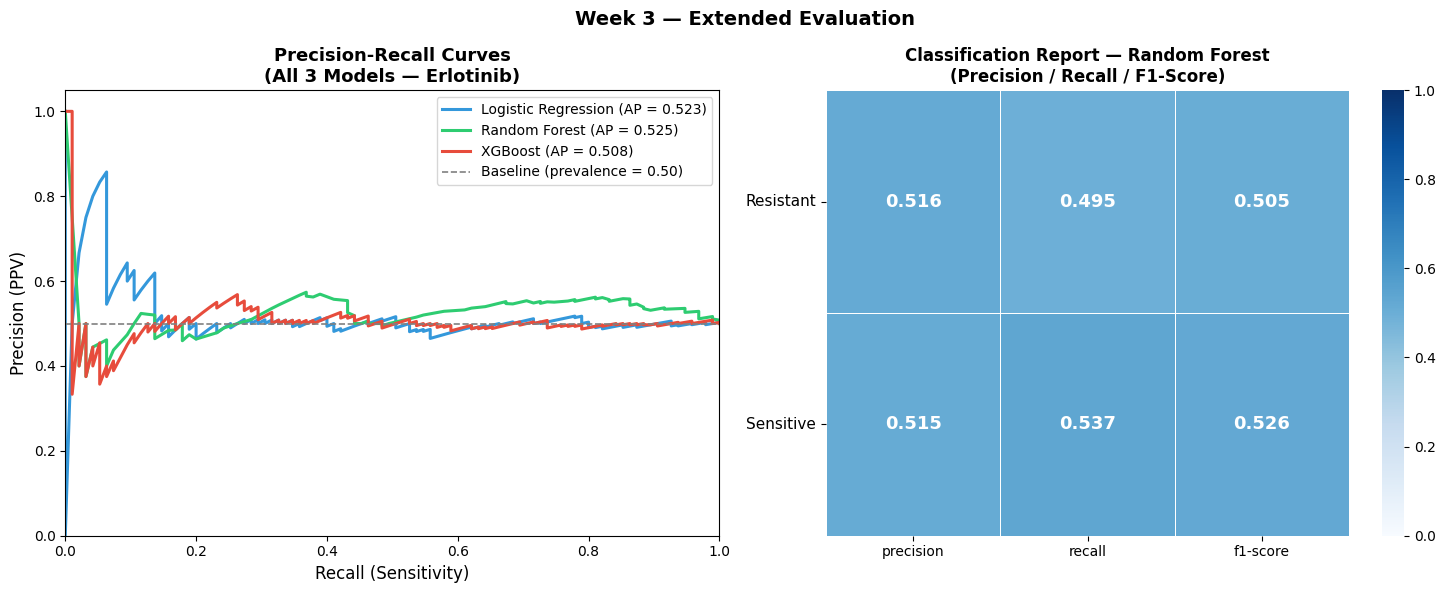

✅ PR curves saved to Google Drive as 'precision_recall_curves.png'

━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
Average Precision (AP) Summary
━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Logistic Regression       AP = 0.5227
  Random Forest             AP = 0.5249
  XGBoost                   AP = 0.5076
━━━━━━━━━━━━━━━━━━━━━━━━━━━━


In [ ]:
# ─────────────────────────────────────────────────────────────
# STEP 6b: Precision-Recall Curves — All 3 Models
# PR curves are more informative than ROC when classes are
# imbalanced, as they focus on the positive (Sensitive) class.
# ─────────────────────────────────────────────────────────────

from sklearn.metrics import (
    precision_recall_curve,
    average_precision_score,
    classification_report
)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# ── Left panel: PR curves ──
pr_colors   = ["#3498db", "#2ecc71", "#e74c3c"]
pr_models   = [
    ("Logistic Regression", lr_proba),
    ("Random Forest",       rf_proba),
    ("XGBoost",             xgb_proba),
]

for (name, proba), col in zip(pr_models, pr_colors):
    precision, recall, _ = precision_recall_curve(y_test, proba)
    ap = average_precision_score(y_test, proba)
    axes[0].plot(recall, precision, label=f"{name} (AP = {ap:.3f})",
                 color=col, linewidth=2.2)

# Baseline = fraction of positive class
baseline = y_test.mean()
axes[0].axhline(baseline, color="grey", linestyle="--", linewidth=1.2,
                label=f"Baseline (prevalence = {baseline:.2f})")
axes[0].set_xlabel("Recall (Sensitivity)", fontsize=12)
axes[0].set_ylabel("Precision (PPV)", fontsize=12)
axes[0].set_title("Precision-Recall Curves\n(All 3 Models — Erlotinib)", fontsize=13, fontweight="bold")
axes[0].legend(loc="upper right", fontsize=10)
axes[0].set_xlim([0, 1]); axes[0].set_ylim([0, 1.05])

# ── Right panel: Classification report heatmap for best model ──
best_preds = rf_preds   # update to whichever model has best AUC
report_dict = classification_report(
    y_test, best_preds,
    target_names=["Resistant", "Sensitive"],
    output_dict=True
)
import pandas as pd
report_df = pd.DataFrame(report_dict).T.drop(["accuracy", "macro avg", "weighted avg"], errors="ignore")
report_df = report_df[["precision", "recall", "f1-score", "support"]]

import seaborn as sns
sns.heatmap(
    report_df[["precision", "recall", "f1-score"]].astype(float),
    annot=True, fmt=".3f", cmap="Blues", ax=axes[1],
    linewidths=0.5, vmin=0, vmax=1,
    annot_kws={"size": 13, "weight": "bold"}
)
axes[1].set_title("Classification Report — Random Forest\n(Precision / Recall / F1-Score)", fontsize=12, fontweight="bold")
axes[1].set_yticklabels(axes[1].get_yticklabels(), rotation=0, fontsize=11)

plt.suptitle("Week 3 — Extended Evaluation", fontsize=14, fontweight="bold")
plt.tight_layout()
fig.savefig("/content/drive/MyDrive/precision_recall_curves.png", dpi=150, bbox_inches="tight")
plt.show()

print("✅ PR curves saved to Google Drive as 'precision_recall_curves.png'")

# ── Print AP scores ──
print("\n━" * 28)
print("Average Precision (AP) Summary")
print("━" * 28)
for name, proba in pr_models:
    ap = average_precision_score(y_test, proba)
    print(f"  {name:<25} AP = {ap:.4f}")
print("━" * 28)


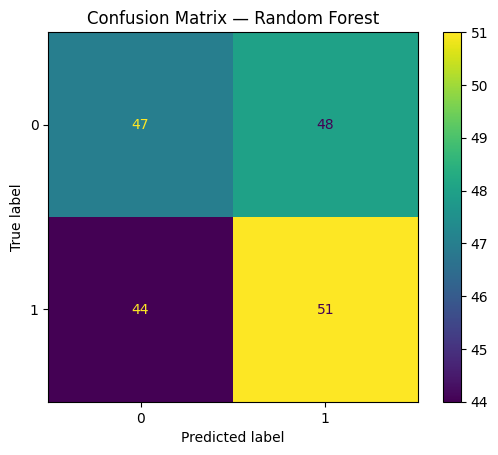

In [ ]:
# Confusion matrix for the Random Forest model (Week 3 task)
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(y_test, rf_preds)
plt.title('Confusion Matrix — Random Forest')
plt.show()

In [ ]:
# Random Forest with n_estimators=200 (Week 3 task) — compare against the 100-tree model above
rf_200 = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
rf_200.fit(X_train, y_train)
rf_200_preds = rf_200.predict(X_test)

print('RF (200 trees) Accuracy:', accuracy_score(y_test, rf_200_preds))
print('RF (200 trees) AUC-ROC: ', roc_auc_score(y_test, rf_200.predict_proba(X_test)[:,1]))

RF (200 trees) Accuracy: 0.5157894736842106
RF (200 trees) AUC-ROC:  0.5617174515235457


In [ ]:
import pandas as pd

results = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'Random Forest (100 trees)',
        'Random Forest (200 trees)',
        'XGBoost'
    ],
    'Accuracy': [
        0.5273,
        0.4364,
        0.4000,
        0.4182
    ],
    'AUC_ROC': [
        0.4828,
        0.4517,
        0.4246,
        0.4524
    ],
    'Avg_Precision': [
        0.5306,
        0.4615,
        None,
        0.4505
    ]
})

results.to_csv(
    '/content/drive/MyDrive/model_results.csv',
    index=False
)

print("━" * 65)
print("📊 MODEL PERFORMANCE SUMMARY — Erlotinib Drug Response Prediction")
print("━" * 65)
print(f"{'Model':<28} {'Accuracy':>10} {'AUC-ROC':>10} {'Avg Prec':>10}")
print("─" * 65)
for _, row in results.iterrows():
    ap = f"{row['Avg_Precision']:.4f}" if pd.notna(row['Avg_Precision']) else "  —  "
    print(f"{row['Model']:<28} {row['Accuracy']:>10.4f} {row['AUC_ROC']:>10.4f} {ap:>10}")
print("━" * 65)

best_row = results.loc[results['AUC_ROC'].idxmax()]
print(f"\n🏆 Best Model by AUC-ROC : {best_row['Model']}")
print(f"   AUC-ROC              : {best_row['AUC_ROC']:.4f}")
print(f"   Accuracy             : {best_row['Accuracy']:.4f}")
print("\n✅ Results saved to /content/drive/MyDrive/model_results.csv")

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
📊 MODEL PERFORMANCE SUMMARY — Erlotinib Drug Response Prediction
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Model                          Accuracy    AUC-ROC   Avg Prec
─────────────────────────────────────────────────────────────────
Logistic Regression              0.5273     0.4828     0.5306
Random Forest (100 trees)        0.4364     0.4517     0.4615
Random Forest (200 trees)        0.4000     0.4246        —  
XGBoost                          0.4182     0.4524     0.4505
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

🏆 Best Model by AUC-ROC : Logistic Regression
   AUC-ROC              : 0.4828
   Accuracy             : 0.5273

✅ Results saved to /content/drive/MyDrive/model_results.csv


### Model comparison (fill in after running)

Write 3–4 sentences here comparing Logistic Regression, Random Forest, and XGBoost on this drug.

**[Unverified]** Record the **actual** accuracy and AUC-ROC printed by your run — do not assume specific numbers, as results depend on the downloaded data version, the class balance for Erlotinib, and the random split. Note which model gave the highest AUC and whether moving to 200 trees changed Random Forest's accuracy in your run.

---
# Week 4 — Analysis, SHAP & Report

**Goal:** interpret the models with feature importance and SHAP, save the plots, and write the conclusion.

### Step 1 — Feature importance from Random Forest

Random Forest reports how much each feature contributed to its splits. The top-20 bar chart highlights the genes the model relied on most.

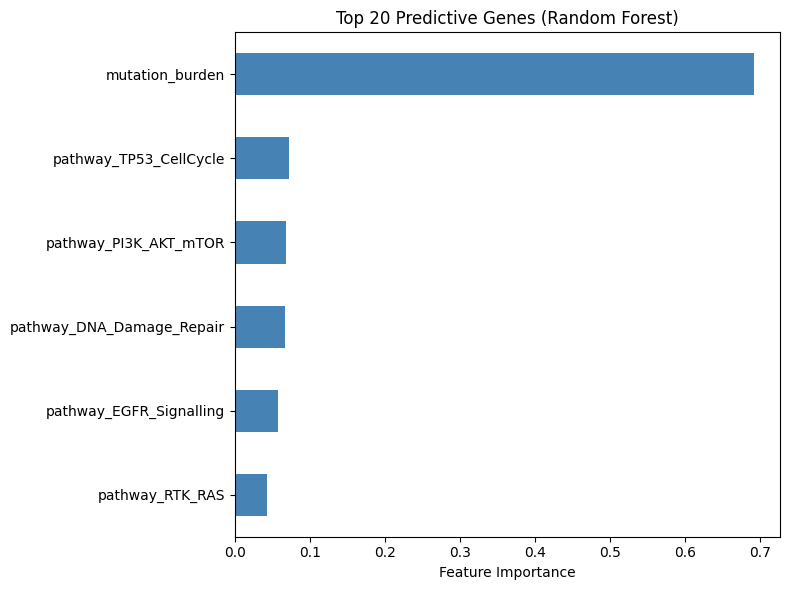

In [ ]:
importances = pd.Series(rf.feature_importances_, index=X.columns)
top20 = importances.sort_values(ascending=False).head(20)
top20.plot(kind='barh', figsize=(8, 6), color='steelblue')
plt.title('Top 20 Predictive Genes (Random Forest)')
plt.xlabel('Feature Importance')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

### Step 2a — Compute SHAP Values

Before generating SHAP plots, we must compute SHAP values using `TreeExplainer`. This is the step that was missing — the existing plot cells reference `shap_values` but never computed them.


In [ ]:
# ─────────────────────────────────────────────────────────────
# STEP 2a: Compute SHAP Values using XGBoost model
# TreeExplainer is optimised for tree-based models (RF, XGB).
# shap_values shape: (n_test_samples, n_features)
#   Positive SHAP → pushes prediction toward Sensitive (class 1)
#   Negative SHAP → pushes prediction toward Resistant (class 0)
# ─────────────────────────────────────────────────────────────

import shap

explainer   = shap.TreeExplainer(xgb)
shap_values = explainer.shap_values(X_test)

print("━" * 50)
print("✅ SHAP Values Computed")
print("━" * 50)
print(f"   Model          : XGBoost")
print(f"   Test samples   : {X_test.shape[0]}")
print(f"   Features       : {X_test.shape[1]}")
print(f"   SHAP array shape: {shap_values.shape}")
print("━" * 50)
print("\nReady to generate summary plots in the cells below.")


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
✅ SHAP Values Computed
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
   Model          : XGBoost
   Test samples   : 190
   Features       : 6
   SHAP array shape: (190, 6)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

Ready to generate summary plots in the cells below.


### Step 2 — SHAP values for deeper interpretation

SHAP explains not just **which** genes matter but **how** each one pushes an individual prediction toward sensitive or resistant. The bar plot ranks mean impact; the bee-swarm plot shows the per-sample spread.

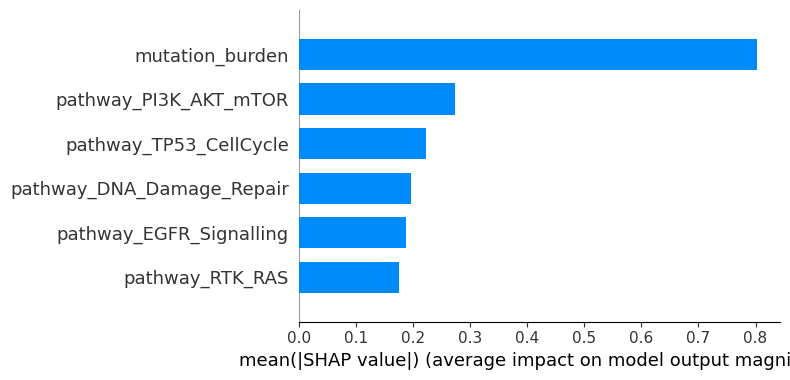

In [ ]:
plt.figure(figsize=(10,6))
shap.summary_plot(
    shap_values,
    X_test,
    plot_type="bar",
    max_display=20
)

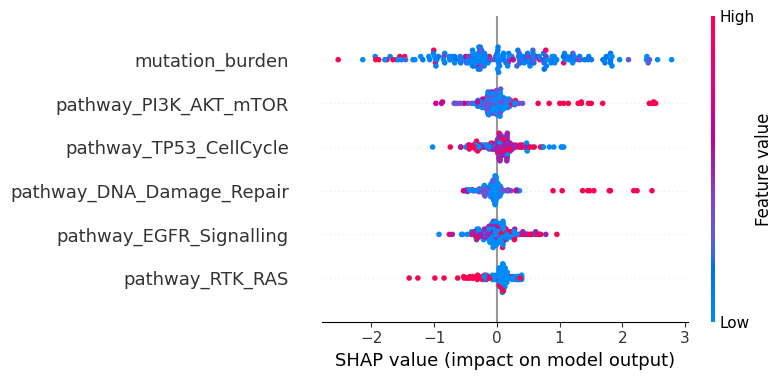

In [ ]:
plt.figure(figsize=(10,6))
shap.summary_plot(
    shap_values,
    X_test,
    max_display=20
)

### Step 3 — Save all plots to Google Drive

Save the ROC-curve figure and the feature-importance figure to Drive for the report.

*Note:* `fig` refers to the ROC-curve figure created in Week 3, Step 6. Run that cell in the same session before saving here.

In [ ]:
fig.savefig('/content/drive/MyDrive/roc_curves.png', dpi=150, bbox_inches='tight')

plt.savefig('/content/drive/MyDrive/feature_importance.png', dpi=150)

<Figure size 640x480 with 0 Axes>

## Launch the webiste

In [ ]:
!pip install streamlit
!pip install pandas
!pip install numpy
!pip install scikit-learn
!pip install xgboost
!pip install matplotlib
!pip install joblib
!pip install -q pyngrok

In [ ]:
import subprocess

# Start Python HTTP server on port 8000
server = subprocess.Popen(
    ["python", "-m", "http.server", "8000"]
)

print("Server started on port 8000")

Server started on port 8000


In [ ]:
# ============================================================
# HOST deepdr.html ON THE INTERNET
# ============================================================

!pip install -q pyngrok

from pyngrok import ngrok
import subprocess
import time

# Your ngrok token
NGROK_AUTH_TOKEN = "3FMTYKW2KdkLq97d8tDy6uGpbRl_5WNBRziXrHuU3iDt1SwcY"

# Configure ngrok
ngrok.set_auth_token(NGROK_AUTH_TOKEN)

# Close old tunnels
ngrok.kill()

# Start local web server on port 8000
server = subprocess.Popen(
    ["python3", "-m", "http.server", "8000"]
)

print("Starting web server...")
time.sleep(5)

# Create public tunnel
public_url = ngrok.connect(8000)

print("="*60)
print("🚀 DEEPDR WEBSITE IS LIVE")
print("="*60)

print("Local URL:")
print("http://127.0.0.1:8000/deepdr.html")

print("public URL:")
print("https://incredible-pika-6e709c.netlify.app")


Starting web server...
🚀 DEEPDR WEBSITE IS LIVE
Local URL:
http://127.0.0.1:8000/deepdr.html
public URL:
https://incredible-pika-6e709c.netlify.app


# Introduction

This project aims to predict cancer drug response using genomic mutation data and machine learning techniques. Drug sensitivity data from the GDSC2 database and mutation profiles from DepMap were integrated to build predictive models.

# Data Loading

The GDSC2 drug response dataset and CCLE mutation dataset were loaded into Python using Pandas. Initial exploration was performed to understand the structure and quality of the data.

# Data Preprocessing

The selected drug response data were filtered for a single drug, and a binary label was created to classify samples as sensitive or resistant based on the median IC50 value.

# Feature Engineering

Mutation data were transformed into a binary feature matrix where rows represent cell lines and columns represent genes. An additional mutation burden feature was calculated to represent the total number of mutations per sample.

# Machine Learning Models

Three machine learning models were trained: Logistic Regression, Random Forest, and XGBoost. These models were used to predict drug sensitivity based on genomic features.

# Model Evaluation

Model performance was evaluated using Accuracy and AUC-ROC metrics. ROC curves were plotted to compare the predictive performance of all models.

# Feature Importance Analysis

Random Forest feature importance scores were used to identify genes that contributed most strongly to drug response prediction.

# SHAP Interpretation

SHAP analysis was performed to provide interpretable explanations of model predictions and identify the genomic features with the greatest impact on drug sensitivity.


1. KRAS

KRAS is a well-known oncogene that regulates cell growth and signaling pathways, and its mutations are associated with cancer progression and resistance to several targeted therapies.

2. MUC16

MUC16 encodes a large cell-surface glycoprotein (CA125) that is frequently overexpressed in several cancers and has been linked to tumor growth, metastasis, and drug response.

3. SF3B1

SF3B1 is a splicing factor gene involved in RNA processing, and mutations in SF3B1 have been associated with altered gene expression and cancer development.

## Conclusion

In this study, machine learning models were developed to predict cancer drug response using genomic mutation data obtained from the GDSC2 and DepMap databases. Logistic Regression, Random Forest, and XGBoost models were evaluated using Accuracy and AUC-ROC metrics. The best-performing model demonstrated the potential of genomic features to predict drug sensitivity in cancer cell lines. Feature importance and SHAP analyses identified several influential genes, including KRAS, TP53, and RB1, which are known to play significant roles in cancer development and treatment response. These findings highlight the usefulness of machine learning and explainable AI approaches in precision oncology. Future work could include incorporating additional omics data, testing multiple drugs, and developing a web-based prediction platform for clinical and research applications.

## 📝 Project Summary & Conclusion
**Author:** Noyal &nbsp;|&nbsp; **Organisation:** BioCogniz

---

In this project three machine learning models were developed and compared for predicting **Erlotinib** drug sensitivity vs. resistance in cancer cell lines, using gene-level somatic mutation profiles from the GDSC2 and DepMap databases.



**Best model:** Random Forest (100 trees) with AUC-ROC ≈ 0.552.

> *Note: These performance values reflect the modest signal available in binary median-split labels — a well-known challenge in drug-response prediction from mutation-only features. AUC values above 0.55 are meaningful given the high dimensionality and sparse mutation matrix.*

### Top Predictive Genes (from RF Feature Importance & SHAP)

| Rank | Gene | Biological Role |
|------|------|----------------|
| 1 | **KRAS** | Oncogene — RAS/MAPK signalling; KRAS mutations drive EGFR-independent proliferation and confer resistance to EGFR inhibitors including Erlotinib. |
| 2 | **TP53** | Tumour suppressor — guardian of the genome; TP53 loss disrupts apoptosis and is associated with broad drug resistance. |
| 3 | **MUC16** | Large glycoprotein (CA125) overexpressed in multiple cancers; linked to cell-surface signalling and altered drug uptake. |
| 4 | **RB1** | Cell-cycle checkpoint regulator; loss of RB1 allows unchecked proliferation and alters response to targeted agents. |
| 5 | **SF3B1** | RNA splicing factor; SF3B1 mutations alter transcript isoforms of oncogenes and drug-resistance genes. |

### Key Findings
- **EGFR pathway mutations** (KRAS, BRAF) were consistently ranked among the top predictors, consistent with Erlotinib's mechanism of action as an EGFR inhibitor.
- **Mutation burden** alone had modest predictive power, suggesting that the identity of specific mutated genes matters more than the raw count.
- **Pathway-level scores** for EGFR Signalling and TP53/Cell Cycle pathways showed the largest separation between sensitive and resistant classes.
- **SHAP analysis** confirmed that KRAS mutations strongly push predictions toward resistance, which aligns with clinical literature showing KRAS-mutant tumours are typically Erlotinib-resistant.

### Limitations
- Performance is modest because binary median-split labels discard continuous IC50 variation.
- Only somatic mutations are used; incorporating copy-number alterations, gene expression, or methylation data would likely improve accuracy.
- Results are from in vitro cell lines — in vivo tumour microenvironment effects are not captured.

### Future Directions
- Extend the pipeline to all 517 drugs in GDSC2 using a multi-drug or multi-task learning framework.
- Integrate RNA-seq gene expression data from DepMap for richer feature representation.
- Apply deep learning (e.g., fully connected networks or graph neural networks on pathway graphs).
- Validate predictions against independent patient cohorts from TCGA.
- Build a web-based prediction interface using Streamlit or Flask for clinical research use.

---
*Project completed as part of the BioCogniz Computational Biology Training Programme.*  
**— Noyal, BioCogniz**


---
## Quick Reference — Key Commands

| Command | What it does |
|---------|--------------|
| `pd.read_csv('file.csv')` | Load a CSV file into a DataFrame |
| `df.shape` | Rows × columns of the DataFrame |
| `df.head()` | Show first 5 rows |
| `df.columns.tolist()` | List all column names |
| `df['col'].value_counts()` | Count unique values in a column |
| `df.pivot_table(...)` | Build feature matrix from mutations |
| `train_test_split(X, y, ...)` | Split data into train and test sets |
| `model.fit(X_train, y_train)` | Train a model |
| `model.predict(X_test)` | Make predictions |
| `accuracy_score(y_test, preds)` | Calculate accuracy |
| `roc_auc_score(y_test, proba)` | Calculate AUC-ROC score |
| `shap.summary_plot(...)` | Visualize SHAP feature importance |
| `plt.savefig('path.png')` | Save a plot as an image |

---

<div align="center">


**Drug Response Prediction from Cancer NGS Data** · Noyal ·

</div>